# $\rho$ Sweep for Path and Cycle Bond Informations

This notebook shows that the vanishing and non-vanishing of the Bond Information for the joint factorising according to $1 \mid 234$, which is a bond for both $Path_4$ and $C_4$, does not depend on the value of $\rho$.

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from Modules.gaussian_bond_information import *

sns.set_theme(style="whitegrid")

In [2]:
# Forming bond, range of correlation strengths, and graphs
bond = frozenset({frozenset({0}), frozenset({1, 2, 3})})
rho_range = np.arange(0.01, 0.99, 0.01)

# Creating graphs
path_4 = nx.path_graph(4)
C_4 = nx.cycle_graph(4)

In [3]:
# Calculating
path_dict = {}
cycle_dict = {}

for rho in rho_range:

    # Form covariance for the bond and calculate BI for current rho
    sigma = covariance_matrix_bond(bond, rho)
    bi_path = analytic_gaussian_bi(path_4, walk_bond_finder, sigma)
    bi_cycle = analytic_gaussian_bi(C_4, walk_bond_finder, sigma)

    # Add to dictionary
    path_dict[rho] = bi_path
    cycle_dict[rho] = bi_cycle

In [4]:
print(f"The cycle bond information is non-zero for all values of rho: {not np.allclose(list(cycle_dict.values())[1:], 0)}")
print(f"The path bond information is zero for all values of rho: {np.allclose(list(path_dict.values())[1:], 0)}")

The cycle bond information is non-zero for all values of rho: True
The path bond information is zero for all values of rho: True


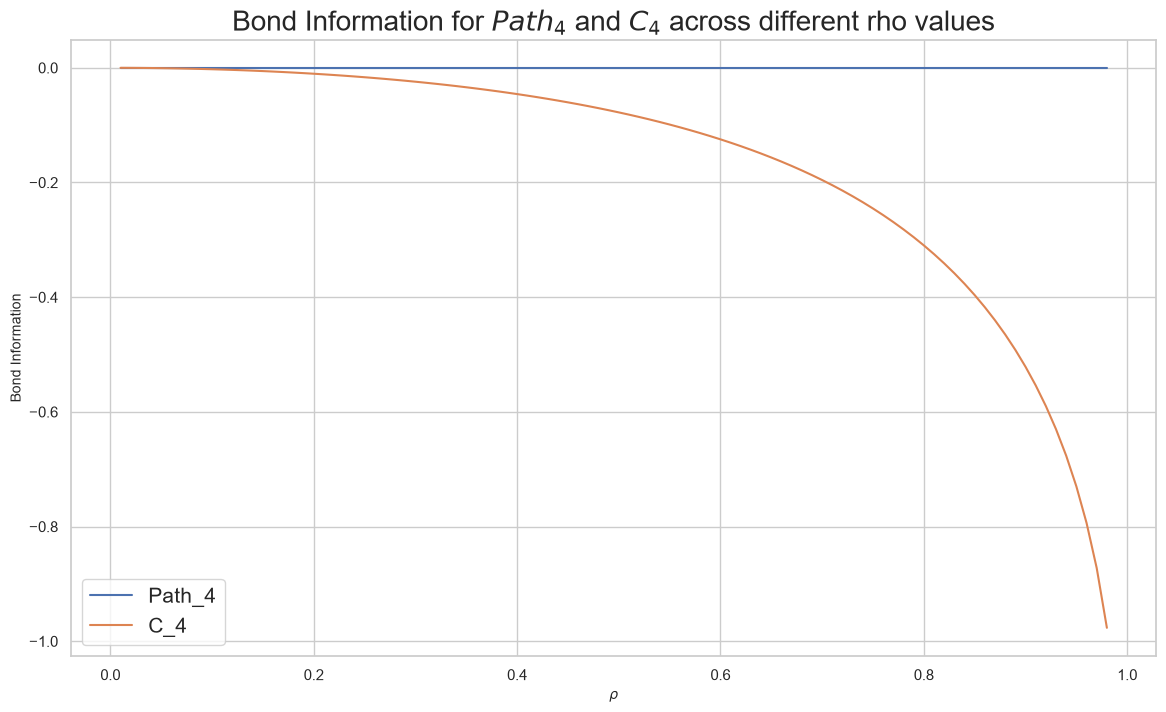

In [5]:
# Plotting
fig, ax = plt.subplots(1, figsize=(14, 8))

ax.plot(path_dict.keys(), path_dict.values(), label="Path_4")
ax.plot(cycle_dict.keys(), cycle_dict.values(), label="C_4")
ax.legend(fontsize=15)
ax.set_xlabel(r"$\rho$", fontsize=10)
ax.set_ylabel("Bond Information", fontsize=10)
ax.set_title(r"Bond Information for $Path_4$ and $C_4$ across different rho values", fontsize=20)

plt.show()